In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Preprocessing

In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


# ============================================================
# 2. LOAD DATASET
# ============================================================

file_path = "/content/drive/MyDrive/DM/mining_features.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 3. CHECK DATASET
# ============================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nOriginal class distribution:")
print(df["label"].value_counts())

print("\nOriginal class distribution (%):")
print(df["label"].value_counts(normalize=True) * 100)


# ============================================================
# 4. REMOVE RAW URL COLUMN
# ============================================================

# The raw URL is not used because we already have
# extracted numerical URL features.

df_processed = df.drop(columns=["url"])

print("\nDataset after removing URL:")
print(df_processed.shape)


# ============================================================
# 5. SEPARATE FEATURES AND TARGET
# ============================================================

X = df_processed.drop(columns=["label"])
y = df_processed["label"]

print("\nFeature columns:")
print(X.columns.tolist())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 6. FIRST SPLIT: 80% TRAIN + 20% TEMPORARY
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ============================================================
# 7. SECOND SPLIT: 10% VALIDATION + 10% TEST
# ============================================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# ============================================================
# 8. CHECK SPLIT SIZES
# ============================================================

print("\n================ DATASET SPLIT ================")

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

print("\nTotal samples:",
      len(X_train) + len(X_val) + len(X_test))

print("\nSplit percentages:")
print(f"Train:      {len(X_train)/len(X)*100:.2f}%")
print(f"Validation: {len(X_val)/len(X)*100:.2f}%")
print(f"Test:       {len(X_test)/len(X)*100:.2f}%")


# ============================================================
# 9. CLASS DISTRIBUTION
# ============================================================

print("\n================ CLASS DISTRIBUTION ================")

print("\nTraining:")
print(y_train.value_counts())

print("\nValidation:")
print(y_val.value_counts())

print("\nTesting:")
print(y_test.value_counts())


print("\nTraining (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation (%):")
print(y_val.value_counts(normalize=True) * 100)

print("\nTesting (%):")
print(y_test.value_counts(normalize=True) * 100)


# ============================================================
# 10. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test using the same scaler
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 11. APPLY SMOTE ONLY TO TRAINING DATA
# ============================================================

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)


# ============================================================
# 12. CHECK SMOTE RESULTS
# ============================================================

print("\n================ SMOTE RESULTS ================")

print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())

print("\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nTraining data BEFORE SMOTE:")
print(X_train_scaled.shape)

print("\nTraining data AFTER SMOTE:")
print(X_train_smote.shape)

print("\nValidation data:")
print(X_val_scaled.shape)

print("\nTest data:")
print(X_test_scaled.shape)


# ============================================================
# 13. FINAL FEATURE NAMES
# ============================================================

print("\n================ FINAL FEATURES ================")

for i, feature in enumerate(X.columns, 1):
    print(f"{i}. {feature}")

Dataset shape: (7307, 9)

Columns:
['url', 'label', 'url_length', 'path_length', 'subdomain_count', 'is_https', 'domain_length', 'has_hyphen', 'digit_count']

First 5 rows:


,url,label,url_length,path_length,subdomain_count,is_https,domain_length,has_hyphen,digit_count
0,https://managesafety.zem.gjb.mybluehost.me/,1,43,1,3,1,34,0,0
1,https://pure-wallet-label.blogspot.com/2025/07...,1,84,46,1,1,30,1,6
2,https://blueconcept.ae/wp-includes/tiop/radium...,1,62,40,0,1,14,0,0
3,https://66d1184a457a7352d91f3481--chipper-star...,1,70,1,1,1,61,1,22
4,https://www-thediamondempirellc-com.filesusr.c...,1,98,50,1,1,40,1,24



Missing values:
url                0
label              0
url_length         0
path_length        0
subdomain_count    0
is_https           0
domain_length      0
has_hyphen         0
digit_count        0
dtype: int64

Original class distribution:
label
1    6713
0     594
Name: count, dtype: int64

Original class distribution (%):
label
1    91.870809
0     8.129191
Name: proportion, dtype: float64

Dataset after removing URL:
(7307, 8)

Feature columns:
['url_length', 'path_length', 'subdomain_count', 'is_https', 'domain_length', 'has_hyphen', 'digit_count']

Feature shape: (7307, 7)
Target shape: (7307,)

================ DATASET SPLIT ================
Training set: (5845, 7)
Validation set: (731, 7)
Testing set: (731, 7)

Total samples: 7307

Split percentages:
Train:      79.99%
Validation: 10.00%
Test:       10.00%

================ CLASS DISTRIBUTION ================

Training:
label
1    5370
0     475
Name: count, dtype: int64

Validation:
label
1    671
0     60
Name: count,

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


Classifications with SMOTE

In [ ]:
# ============================================================
# CLASSIFICATION ONLY
# ============================================================

import pandas as pd
import pickle

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Classical classifiers
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------------------------
# Advanced boosting classifiers
# ------------------------------------------------------------

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ============================================================
# CLASSIFIERS
# ============================================================

classifiers = {

    # --------------------------------------------------------
    # Linear Models
    # --------------------------------------------------------

    "LR": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SGD Classifier": SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ),

    # --------------------------------------------------------
    # Tree-Based Models
    # --------------------------------------------------------

    "DT": DecisionTreeClassifier(
        random_state=42
    ),

    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # Boosting Models
    # --------------------------------------------------------

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    # --------------------------------------------------------
    # CatBoost
    # --------------------------------------------------------

    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=10,
        l2_leaf_reg=3,
        border_count=32,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    ),

    # --------------------------------------------------------
    # Naive Bayes
    # --------------------------------------------------------

    "NB": GaussianNB(),

    # --------------------------------------------------------
    # Neural Network
    # --------------------------------------------------------

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=500,
        random_state=42
    ),

    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------

    "Linear SVC": LinearSVC(
        C=0.01,
        loss="squared_hinge",
        max_iter=1000,
        random_state=42
    ),

    "SVC": SVC(
        kernel="rbf",
        random_state=42
    ),

    # --------------------------------------------------------
    # Distance-Based
    # --------------------------------------------------------

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        n_jobs=-1
    )
}


# ============================================================
# STORE RESULTS
# ============================================================

results = []
predictions = {}


# ============================================================
# TRAIN AND EVALUATE
# ============================================================

for model_name, classifier in classifiers.items():

    print("\n")
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    classifier.fit(
        X_train_smote,
        y_train_smote
    )


    # ========================================================
    # TRAINING RESULTS
    # ========================================================

    train_prediction = classifier.predict(
        X_train_smote
    )

    print("\nTraining Results")
    print("----------------")

    print(
        "Accuracy:",
        accuracy_score(
            y_train_smote,
            train_prediction
        )
    )

    print(
        "Precision:",
        precision_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )

    print(
        "Recall:",
        recall_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    validation_prediction = classifier.predict(
        X_val_scaled
    )

    print("\nValidation Results")
    print("------------------")

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_val,
            validation_prediction
        )
    )

    validation_accuracy = accuracy_score(
        y_val,
        validation_prediction
    )

    validation_precision = precision_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    validation_recall = recall_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    validation_f1 = f1_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    print(
        "Accuracy:",
        validation_accuracy
    )

    print(
        "Precision:",
        validation_precision
    )

    print(
        "Recall:",
        validation_recall
    )

    print(
        "F1 Score:",
        validation_f1
    )


    # ========================================================
    # TEST RESULTS
    # ========================================================

    test_prediction = classifier.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    precision = precision_score(
        y_test,
        test_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_prediction,
        zero_division=0
    )


    # ========================================================
    # ROC-AUC
    # ========================================================

    try:

        if hasattr(classifier, "predict_proba"):

            test_scores = classifier.predict_proba(
                X_test_scaled
            )[:, 1]

        elif hasattr(classifier, "decision_function"):

            test_scores = classifier.decision_function(
                X_test_scaled
            )

        else:

            test_scores = test_prediction

        roc_auc = roc_auc_score(
            y_test,
            test_scores
        )

    except Exception:

        roc_auc = None


    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    predictions[model_name] = test_prediction


    # ========================================================
    # PRINT TEST RESULTS
    # ========================================================

    print("\nTest Results")
    print("------------")

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            test_prediction
        )
    )

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)


    # ========================================================
    # CLASS-WISE PERFORMANCE
    # ========================================================

    print("\nClass-wise Performance")
    print("----------------------")

    print(
        classification_report(
            y_test,
            test_prediction,
            labels=[0, 1],
            target_names=[
                "Class 0",
                "Class 1"
            ],
            digits=4,
            zero_division=0
        )
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL CLASSIFIER COMPARISON")
print("=" * 80)

print(
    results_df.to_string(index=False)
)


# ============================================================
# SORT BY F1 SCORE
# ============================================================

results_sorted = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n")
print("=" * 80)
print("CLASSIFIERS RANKED BY F1 SCORE")
print("=" * 80)

print(
    results_sorted.to_string(index=False)
)


# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "/content/drive/MyDrive/DM/mining_classifier_results1.csv",
    index=False
)


# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

with open(
    "/content/drive/MyDrive/DM/mining_model_predictions.pkl",
    "wb"
) as f:

    pickle.dump(
        predictions,
        f
    )


print("\nResults saved successfully.")
print("Predictions saved successfully.")



LR

Training Results
----------------
Accuracy: 0.9077281191806331
Precision: 0.9305801376597836
Recall: 0.8811918063314711
F1 Score: 0.9052128168340507

Validation Results
------------------
Confusion Matrix:
[[ 56   4]
 [ 75 596]]
Accuracy: 0.8919288645690835
Precision: 0.9933333333333333
Recall: 0.8882265275707899
F1 Score: 0.937844217151849

Test Results
------------
Confusion Matrix:
[[ 56   3]
 [ 77 595]]
Accuracy: 0.8905608755129959
Precision: 0.9949832775919732
Recall: 0.8854166666666666
F1 Score: 0.937007874015748
ROC-AUC: 0.9519395682001613

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.4211    0.9492    0.5833        59
     Class 1     0.9950    0.8854    0.9370       672

    accuracy                         0.8906       731
   macro avg     0.7080    0.9173    0.7602       731
weighted avg     0.9487    0.8906    0.9085       731



SGD Classifier

Training Results
----------------
Accuracy: 0.903

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training Results
----------------
Accuracy: 0.9884543761638733
Precision: 0.9926746806912096
Recall: 0.984171322160149
F1 Score: 0.9884047129231345

Validation Results
------------------
Confusion Matrix:
[[ 49  11]
 [ 16 655]]
Accuracy: 0.9630642954856361
Precision: 0.9834834834834835
Recall: 0.9761549925484352
F1 Score: 0.9798055347793567

Test Results
------------
Confusion Matrix:
[[ 42  17]
 [ 25 647]]
Accuracy: 0.9425444596443229
Precision: 0.9743975903614458
Recall: 0.9627976190476191
F1 Score: 0.968562874251497
ROC-AUC: 0.9675015133171911

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.6269    0.7119    0.6667        59
     Class 1     0.9744    0.9628    0.9686       672

    accuracy                         0.9425       731
   macro avg     0.8006    0.8373    0.8176       731
weighted avg     0.9463    0.9425    0.9442       731



CatBoost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training Results
----------------
Accuracy: 0.9685288640595903
Precision: 0.9894941634241246
Recall: 0.9471135940409683
F1 Score: 0.9678401522359658

Validation Results
------------------
Confusion Matrix:
[[ 52   8]
 [ 36 635]]
Accuracy: 0.9398084815321477
Precision: 0.9875583203732504
Recall: 0.9463487332339792
F1 Score: 0.9665144596651446

Test Results
------------
Confusion Matrix:
[[ 47  12]
 [ 48 624]]
Accuracy: 0.9179206566347469
Precision: 0.9811320754716981
Recall: 0.9285714285714286
F1 Score: 0.9541284403669725
ROC-AUC: 0.9694688256658596

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.4947    0.7966    0.6104        59
     Class 1     0.9811    0.9286    0.9541       672

    accuracy                         0.9179       731
   macro avg     0.7379    0.8626    0.7823       731
weighted avg     0.9419    0.9179    0.9264       731



NB

Training Results
----------------
Accuracy: 0.8759776536312849
P

Classification Without SMOTE

In [ ]:
# ============================================================
# CLASSIFICATION ONLY
# ============================================================

import pandas as pd
import pickle

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Classical classifiers
# ------------------------------------------------------------

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------------------------
# Advanced boosting classifiers
# ------------------------------------------------------------

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# ============================================================
# CLASSIFIERS
# ============================================================

classifiers = {

    # --------------------------------------------------------
    # Linear Models
    # --------------------------------------------------------

    "LR": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "SGD Classifier": SGDClassifier(
        loss="hinge",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        random_state=42
    ),

    # --------------------------------------------------------
    # Tree-Based Models
    # --------------------------------------------------------

    "DT": DecisionTreeClassifier(
        random_state=42
    ),

    "RF": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # Boosting Models
    # --------------------------------------------------------

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=100,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ),

    # --------------------------------------------------------
    # XGBoost
    # --------------------------------------------------------

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    # --------------------------------------------------------
    # LightGBM
    # --------------------------------------------------------

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    # --------------------------------------------------------
    # CatBoost
    # --------------------------------------------------------

    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=10,
        l2_leaf_reg=3,
        border_count=32,
        loss_function="Logloss",
        verbose=False,
        random_seed=42
    ),

    # --------------------------------------------------------
    # Naive Bayes
    # --------------------------------------------------------

    "NB": GaussianNB(),

    # --------------------------------------------------------
    # Neural Network
    # --------------------------------------------------------

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=500,
        random_state=42
    ),

    # --------------------------------------------------------
    # SVM
    # --------------------------------------------------------

    "Linear SVC": LinearSVC(
        C=0.01,
        loss="squared_hinge",
        max_iter=1000,
        random_state=42
    ),

    "SVC": SVC(
        kernel="rbf",
        random_state=42
    ),

    # --------------------------------------------------------
    # Distance-Based
    # --------------------------------------------------------

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="minkowski",
        n_jobs=-1
    )
}


# ============================================================
# STORE RESULTS
# ============================================================

results = []
predictions = {}


# ============================================================
# TRAIN AND EVALUATE
# ============================================================

for model_name, classifier in classifiers.items():

    print("\n")
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    classifier.fit(
        X_train_scaled,
        y_train
    )


    # ========================================================
    # TRAINING RESULTS
    # ========================================================

    train_prediction = classifier.predict(
        X_train_smote
    )

    print("\nTraining Results")
    print("----------------")

    print(
        "Accuracy:",
        accuracy_score(
            y_train_smote,
            train_prediction
        )
    )

    print(
        "Precision:",
        precision_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )

    print(
        "Recall:",
        recall_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )

    print(
        "F1 Score:",
        f1_score(
            y_train_smote,
            train_prediction,
            zero_division=0
        )
    )


    # ========================================================
    # VALIDATION RESULTS
    # ========================================================

    validation_prediction = classifier.predict(
        X_val_scaled
    )

    print("\nValidation Results")
    print("------------------")

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_val,
            validation_prediction
        )
    )

    validation_accuracy = accuracy_score(
        y_val,
        validation_prediction
    )

    validation_precision = precision_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    validation_recall = recall_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    validation_f1 = f1_score(
        y_val,
        validation_prediction,
        zero_division=0
    )

    print(
        "Accuracy:",
        validation_accuracy
    )

    print(
        "Precision:",
        validation_precision
    )

    print(
        "Recall:",
        validation_recall
    )

    print(
        "F1 Score:",
        validation_f1
    )


    # ========================================================
    # TEST RESULTS
    # ========================================================

    test_prediction = classifier.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    precision = precision_score(
        y_test,
        test_prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        test_prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        test_prediction,
        zero_division=0
    )


    # ========================================================
    # ROC-AUC
    # ========================================================

    try:

        if hasattr(classifier, "predict_proba"):

            test_scores = classifier.predict_proba(
                X_test_scaled
            )[:, 1]

        elif hasattr(classifier, "decision_function"):

            test_scores = classifier.decision_function(
                X_test_scaled
            )

        else:

            test_scores = test_prediction

        roc_auc = roc_auc_score(
            y_test,
            test_scores
        )

    except Exception:

        roc_auc = None


    # ========================================================
    # SAVE TEST PREDICTIONS
    # ========================================================

    predictions[model_name] = test_prediction


    # ========================================================
    # PRINT TEST RESULTS
    # ========================================================

    print("\nTest Results")
    print("------------")

    print("Confusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            test_prediction
        )
    )

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)


    # ========================================================
    # CLASS-WISE PERFORMANCE
    # ========================================================

    print("\nClass-wise Performance")
    print("----------------------")

    print(
        classification_report(
            y_test,
            test_prediction,
            labels=[0, 1],
            target_names=[
                "Class 0",
                "Class 1"
            ],
            digits=4,
            zero_division=0
        )
    )


    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })


# ============================================================
# FINAL RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("FINAL CLASSIFIER COMPARISON")
print("=" * 80)

print(
    results_df.to_string(index=False)
)


# ============================================================
# SORT BY F1 SCORE
# ============================================================

results_sorted = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

print("\n")
print("=" * 80)
print("CLASSIFIERS RANKED BY F1 SCORE")
print("=" * 80)

print(
    results_sorted.to_string(index=False)
)


# ============================================================
# SAVE RESULTS
# ============================================================

results_df.to_csv(
    "/content/drive/MyDrive/DM/mining_classifier_results.csv",
    index=False
)


# ============================================================
# SAVE TEST PREDICTIONS
# ============================================================

with open(
    "/content/drive/MyDrive/DM/mining_model_predictions.pkl",
    "wb"
) as f:

    pickle.dump(
        predictions,
        f
    )


print("\nResults saved successfully.")
print("Predictions saved successfully.")



LR

Training Results
----------------
Accuracy: 0.7370577281191807
Precision: 0.659683893627697
Recall: 0.9793296089385475
F1 Score: 0.7883375805726278

Validation Results
------------------
Confusion Matrix:
[[ 35  25]
 [  8 663]]
Accuracy: 0.9548563611491108
Precision: 0.9636627906976745
Recall: 0.9880774962742176
F1 Score: 0.9757174392935982

Test Results
------------
Confusion Matrix:
[[ 26  33]
 [ 19 653]]
Accuracy: 0.9288645690834473
Precision: 0.9518950437317785
Recall: 0.9717261904761905
F1 Score: 0.9617083946980854
ROC-AUC: 0.9536798829701372

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.5778    0.4407    0.5000        59
     Class 1     0.9519    0.9717    0.9617       672

    accuracy                         0.9289       731
   macro avg     0.7648    0.7062    0.7309       731
weighted avg     0.9217    0.9289    0.9244       731



SGD Classifier

Training Results
----------------
Accuracy: 0.72

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training Results
----------------
Accuracy: 0.8962756052141527
Precision: 0.8304347826086956
Recall: 0.9959031657355679
F1 Score: 0.9056731583403895

Validation Results
------------------
Confusion Matrix:
[[ 45  15]
 [  9 662]]
Accuracy: 0.9671682626538988
Precision: 0.9778434268833087
Recall: 0.9865871833084948
F1 Score: 0.9821958456973294

Test Results
------------
Confusion Matrix:
[[ 37  22]
 [ 14 658]]
Accuracy: 0.9507523939808481
Precision: 0.9676470588235294
Recall: 0.9791666666666666
F1 Score: 0.9733727810650887
ROC-AUC: 0.9669970742534303

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.7255    0.6271    0.6727        59
     Class 1     0.9676    0.9792    0.9734       672

    accuracy                         0.9508       731
   macro avg     0.8466    0.8031    0.8231       731
weighted avg     0.9481    0.9508    0.9491       731



CatBoost


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Training Results
----------------
Accuracy: 0.8794227188081937
Precision: 0.8103579588728104
Recall: 0.9906890130353817
F1 Score: 0.8914956011730205

Validation Results
------------------
Confusion Matrix:
[[ 43  17]
 [ 10 661]]
Accuracy: 0.9630642954856361
Precision: 0.9749262536873157
Recall: 0.9850968703427719
F1 Score: 0.9799851742031134

Test Results
------------
Confusion Matrix:
[[ 38  21]
 [ 13 659]]
Accuracy: 0.9534883720930233
Precision: 0.9691176470588235
Recall: 0.9806547619047619
F1 Score: 0.9748520710059172
ROC-AUC: 0.9699228208232445

Class-wise Performance
----------------------
              precision    recall  f1-score   support

     Class 0     0.7451    0.6441    0.6909        59
     Class 1     0.9691    0.9807    0.9749       672

    accuracy                         0.9535       731
   macro avg     0.8571    0.8124    0.8329       731
weighted avg     0.9510    0.9535    0.9519       731



NB

Training Results
----------------
Accuracy: 0.8715083798882681
P

Evaluation Metrics

Top 5 Models:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
10,CatBoost,0.953488,0.969118,0.980655,0.974852,0.969923
3,RF,0.952120,0.969072,0.979167,0.974093,0.968082
8,XGBoost,0.950752,0.967647,0.979167,0.973373,0.971587
9,LightGBM,0.950752,0.967647,0.979167,0.973373,0.966997
12,MLP,0.949384,0.966226,0.979167,0.972653,0.975648


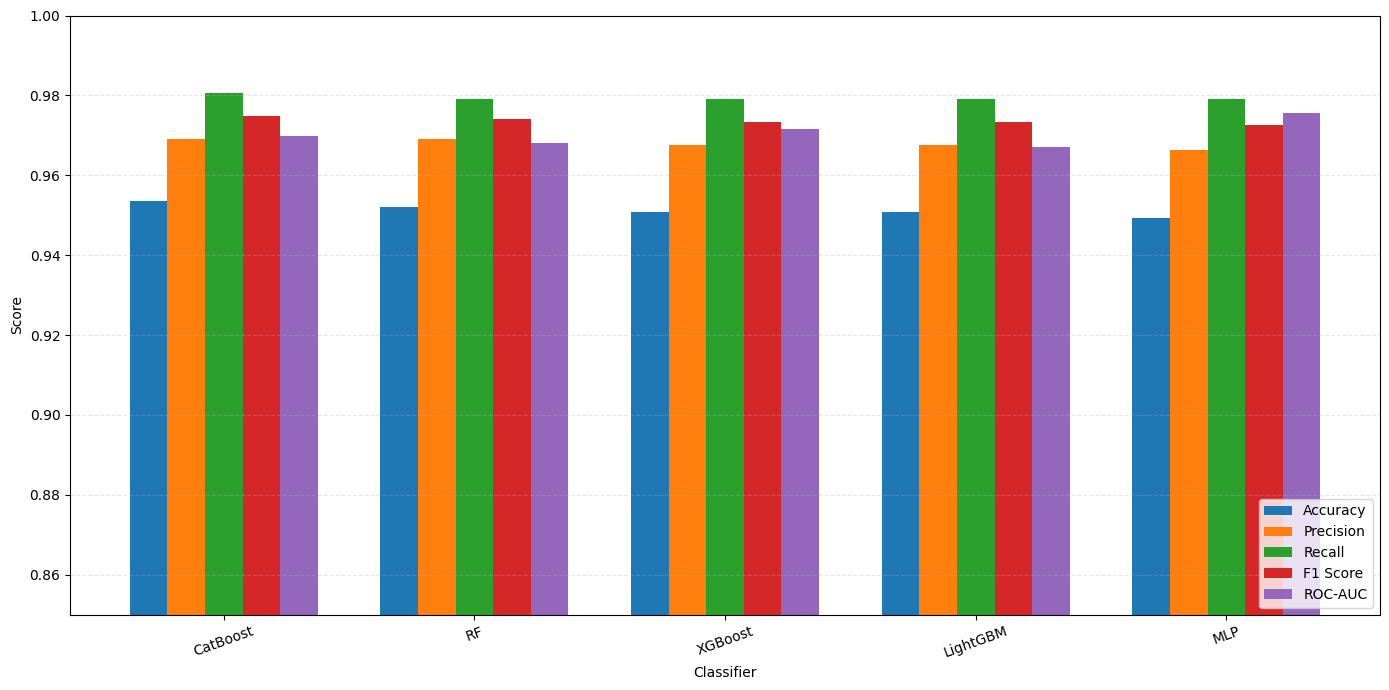

In [ ]:
# ============================================================
# VISUALIZATION OF TOP CLASSIFIERS - WITHOUT SMOTE
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd


# ============================================================
# 1. SELECT TOP MODELS
# ============================================================

top_models = (
    results_df
    .sort_values(by="F1 Score", ascending=False)
    .head(5)
    .copy()
)

print("Top 5 Models:")
display(top_models)


# ============================================================
# 2. PREPARE METRICS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]


# ============================================================
# 3. GROUPED BAR CHART
# ============================================================

x = range(len(top_models))
width = 0.15

plt.figure(figsize=(14, 7))

for i, metric in enumerate(metrics):

    values = top_models[metric].values

    plt.bar(
        [pos + (i - 2) * width for pos in x],
        values,
        width=width,
        label=metric
    )

# X-axis
plt.xticks(
    list(x),
    top_models["Model"],
    rotation=20
)

# Y-axis
plt.ylim(0.85, 1.00)

plt.ylabel("Score")
plt.xlabel("Classifier")

#title(
  #  "Performance Comparison of Top Classifiers Without SMOTE"
#)

plt.legend(
    loc="lower right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

F1-score

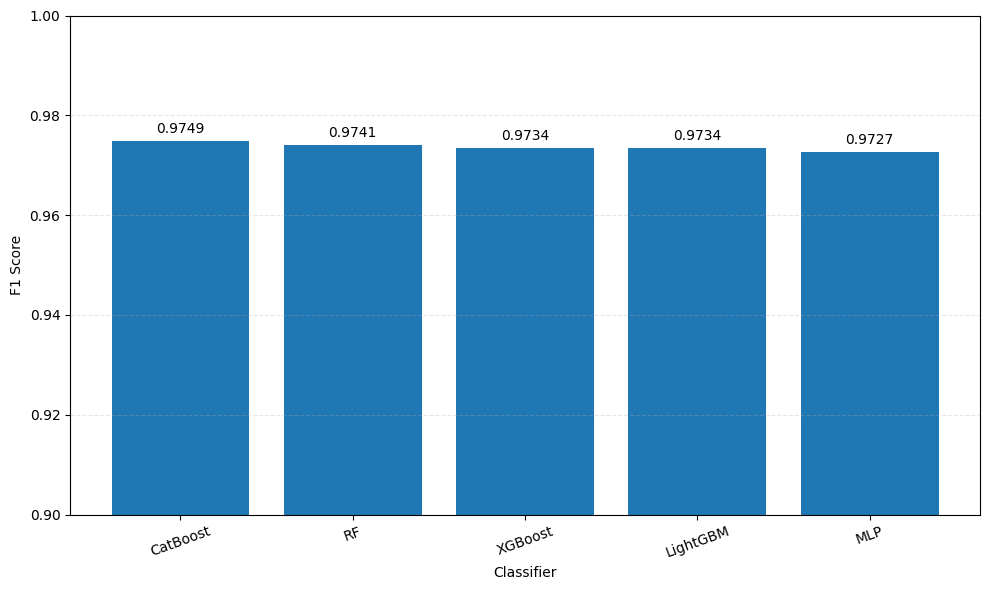

In [ ]:
# ============================================================
# F1 SCORE COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_models["Model"],
    top_models["F1 Score"]
)

plt.ylim(0.90, 1.00)

plt.ylabel("F1 Score")
plt.xlabel("Classifier")

#plt.title(
#"F1 Score Comparison of Top Classifiers Without SMOTE"
#)

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add values above bars
for bar, value in zip(
    bars,
    top_models["F1 Score"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.001,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


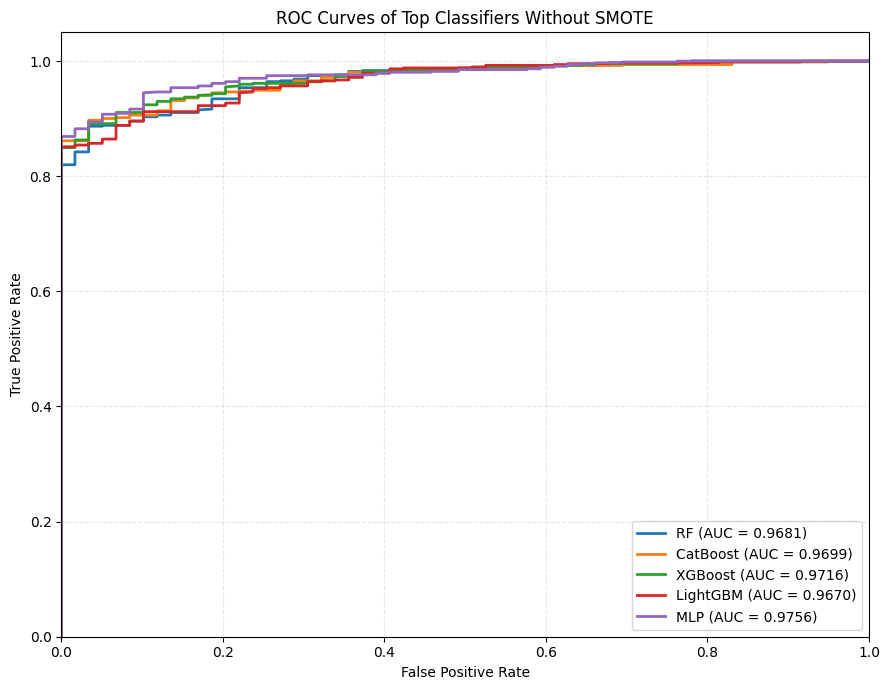

In [ ]:
# ============================================================
# STANDARD ROC CURVE - TOP MODELS WITHOUT SMOTE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ============================================================
# TOP MODELS
# ============================================================

top_models = [
    "RF",
    "CatBoost",
    "XGBoost",
    "LightGBM",
    "MLP"
]


# ============================================================
# TRAIN MODELS AND PLOT ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))

for model_name in top_models:

    classifier = classifiers[model_name]

    # Train WITHOUT SMOTE
    classifier.fit(
        X_train_scaled,
        y_train
    )

    # --------------------------------------------------------
    # Get probability / decision scores
    # --------------------------------------------------------

    if hasattr(classifier, "predict_proba"):

        y_score = classifier.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_score = classifier.decision_function(
            X_test_scaled
        )

    # --------------------------------------------------------
    # ROC Curve
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_value:.4f})"
    )


# ============================================================
# GRAPH FORMATTING
# ============================================================

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves of Top Classifiers Without SMOTE"
)

plt.legend(
    loc="lower right"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

ROC-AUC with Baseline

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


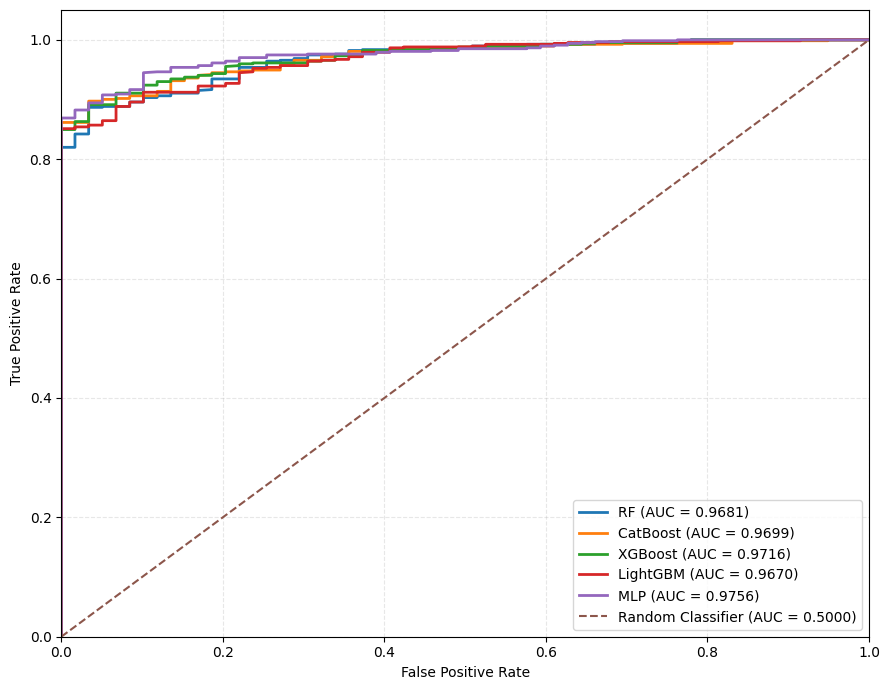

In [ ]:
# ============================================================
# STANDARD ROC CURVE - TOP MODELS WITHOUT SMOTE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# ============================================================
# TOP MODELS
# ============================================================

top_models = [
    "RF",
    "CatBoost",
    "XGBoost",
    "LightGBM",
    "MLP"
]


# ============================================================
# TRAIN MODELS AND PLOT ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))

for model_name in top_models:

    classifier = classifiers[model_name]

    # Train WITHOUT SMOTE
    classifier.fit(
        X_train_scaled,
        y_train
    )

    # --------------------------------------------------------
    # Get probability / decision scores
    # --------------------------------------------------------

    if hasattr(classifier, "predict_proba"):

        y_score = classifier.predict_proba(
            X_test_scaled
        )[:, 1]

    else:

        y_score = classifier.decision_function(
            X_test_scaled
        )

    # --------------------------------------------------------
    # ROC Curve
    # --------------------------------------------------------

    fpr, tpr, _ = roc_curve(
        y_test,
        y_score
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {roc_auc_value:.4f})"
    )


# ============================================================
# RANDOM CLASSIFIER BASELINE
# ============================================================

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random Classifier (AUC = 0.5000)"
)


# ============================================================
# GRAPH FORMATTING
# ============================================================

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

#plt.title(
#"ROC Curves of Top Classifiers Without SMOTE"
#)

plt.legend(
    loc="lower right"
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()

Feature Engineeering

In [ ]:
# ============================================================
# RANDOM FOREST FEATURE RANKING + TOP-K EXPERIMENTS
# MINING DATASET - WITHOUT SMOTE
# ============================================================

import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. FEATURE NAMES
# ============================================================

feature_cols = [
    "url_length",
    "path_length",
    "subdomain_count",
    "is_https",
    "domain_length",
    "has_hyphen",
    "digit_count"
]

target_col = "label"


# ============================================================
# 2. TRAINING / VALIDATION / TEST DATA
# ============================================================

print("Training Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Testing Shape:", X_test.shape)


# ============================================================
# 3. RANDOM FOREST FEATURE RANKING
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# IMPORTANT:
# Feature ranking is performed using the ORIGINAL
# training data WITHOUT SMOTE.

rf.fit(
    X_train,
    y_train
)


# ============================================================
# 4. CALCULATE FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("RANDOM FOREST FEATURE IMPORTANCE RANKING")
print("=" * 80)

print(importance.to_string(index=False))


# ============================================================
# 5. TOP-K FEATURE EXPERIMENTS
# ============================================================

results = []

best_f1 = -1
best_features = None
best_k = None


for k in range(1, len(feature_cols) + 1):

    print("\n")
    print("=" * 80)
    print(f"EXPERIMENT {k}: TOP {k} FEATURE(S)")
    print("=" * 80)


    # --------------------------------------------------------
    # SELECT TOP-K FEATURES
    # --------------------------------------------------------

    top_features = (
        importance
        .head(k)["Feature"]
        .tolist()
    )

    print("\nSelected Features:")
    print(top_features)


    # --------------------------------------------------------
    # SELECT FEATURES FROM TRAINING DATA
    # --------------------------------------------------------

    X_train_selected = X_train[top_features]

    X_validation_selected = (
        X_val[top_features]
    )


    # --------------------------------------------------------
    # TRAIN RANDOM FOREST
    # --------------------------------------------------------

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=1,
        class_weight=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_selected,
        y_train
    )


    # --------------------------------------------------------
    # VALIDATION PREDICTION
    # --------------------------------------------------------

    validationPrediction = model.predict(
        X_validation_selected
    )


    # --------------------------------------------------------
    # VALIDATION METRICS
    # --------------------------------------------------------

    acc = accuracy_score(
        y_val,
        validationPrediction
    )

    prec = precision_score(
        y_val,
        validationPrediction,
        average="binary",
        zero_division=0
    )

    rec = recall_score(
        y_val,
        validationPrediction,
        average="binary",
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        validationPrediction,
        average="binary",
        zero_division=0
    )


    # --------------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------------

    print("\nAccuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1 Score :", round(f1, 4))


    # --------------------------------------------------------
    # CLASSIFICATION REPORT
    # --------------------------------------------------------

    print("\nClassification Report")

    print(
        classification_report(
            y_val,
            validationPrediction,
            digits=4,
            zero_division=0
        )
    )


    # --------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------

    print("\nConfusion Matrix")

    print(
        confusion_matrix(
            y_val,
            validationPrediction
        )
    )


    # --------------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------------

    results.append([
        k,
        ", ".join(top_features),
        acc,
        prec,
        rec,
        f1
    ])


    # --------------------------------------------------------
    # SELECT BEST FEATURE SET
    # --------------------------------------------------------

    if f1 > best_f1:

        best_f1 = f1

        best_features = top_features.copy()

        best_k = k


# ============================================================
# 6. SUMMARY
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        "Top Features",
        "Selected Features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)


print("\n")
print("=" * 80)
print("TOP-K FEATURE EXPERIMENT SUMMARY")
print("=" * 80)

print(
    results_df.to_string(index=False)
)


# ============================================================
# 7. BEST FEATURE SET
# ============================================================

print("\n")
print("=" * 80)
print("BEST FEATURE SET")
print("=" * 80)

print(
    "Best Number of Features:",
    best_k
)

print(
    "Best Validation F1 Score:",
    round(best_f1, 4)
)

print(
    "\nBest Features:"
)

for i, feature in enumerate(
    best_features,
    1
):
    print(
        f"{i}. {feature}"
    )

Training Shape: (5845, 7)
Validation Shape: (731, 7)
Testing Shape: (731, 7)


RANDOM FOREST FEATURE IMPORTANCE RANKING
        Feature  Importance
  domain_length    0.206255
    path_length    0.172846
       is_https    0.154204
     url_length    0.148845
subdomain_count    0.145790
    digit_count    0.088267
     has_hyphen    0.083792


EXPERIMENT 1: TOP 1 FEATURE(S)

Selected Features:
['domain_length']

Accuracy : 0.922
Precision: 0.9217
Recall   : 1.0
F1 Score : 0.9593

Classification Report
              precision    recall  f1-score   support

           0     1.0000    0.0500    0.0952        60
           1     0.9217    1.0000    0.9593       671

    accuracy                         0.9220       731
   macro avg     0.9609    0.5250    0.5272       731
weighted avg     0.9281    0.9220    0.8883       731


Confusion Matrix
[[  3  57]
 [  0 671]]


EXPERIMENT 2: TOP 2 FEATURE(S)

Selected Features:
['domain_length', 'path_length']

Accuracy : 0.9179
Precision: 0.9214
Re

Plotting feature important ranking

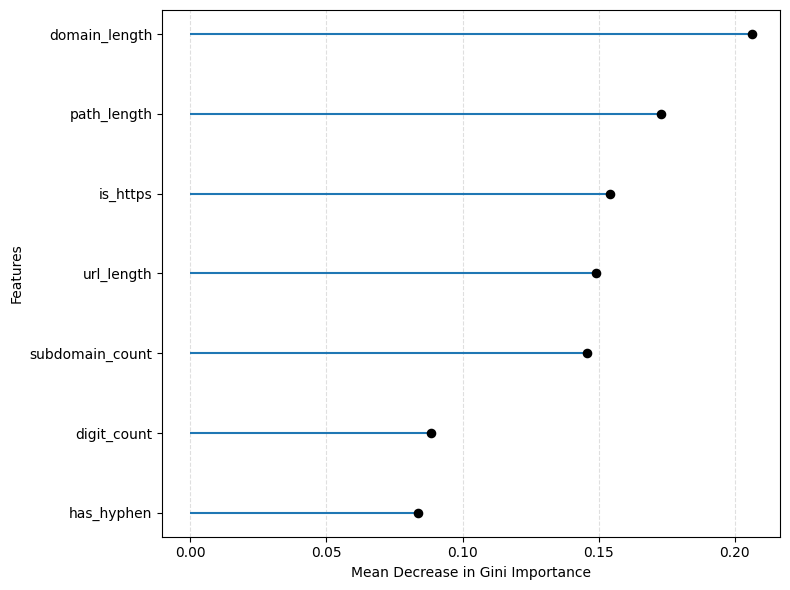

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================
# Prepare data
# =====================================

plot_df = importance.sort_values("Importance", ascending=True)

features = plot_df["Feature"]
scores = plot_df["Importance"]

# =====================================
# Plot
# =====================================

plt.figure(figsize=(8,6))

plt.scatter(
    scores,
    features,
    color="black",
    s=35,
    zorder=3
)

# Horizontal line through each point
for y, x in enumerate(scores):
    plt.hlines(
        y=y,
        xmin=0,
        xmax=x,
        linewidth=1.5
    )

plt.xlabel("Mean Decrease in Gini Importance")
plt.ylabel("Features")
#plt.title("Random Forest Feature Importance")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

Random Forest optimal parameters

CATBOOST HYPERPARAMETER TUNING

In [ ]:
# ============================================================
# CATBOOST HYPERPARAMETER TUNING
# WITHOUT SMOTE
# ============================================================

from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV


# ============================================================
# 1. BEST 7 FEATURES
# ============================================================

best_features = [
    "domain_length",
    "path_length",
    "is_https",
    "url_length",
    "subdomain_count",
    "digit_count",
    "has_hyphen"
]

X_train_best = X_train[best_features]

print("Selected Features:")
for i, feature in enumerate(best_features, 1):
    print(f"{i}. {feature}")

print("\nTraining Shape:", X_train_best.shape)


# ============================================================
# 2. CATBOOST MODEL
# ============================================================

catboost_model = CatBoostClassifier(
    random_seed=42,
    verbose=0,
    thread_count=-1
)


# ============================================================
# 3. HYPERPARAMETER GRID
# ============================================================

param_grid = {

    "iterations": [200, 300, 500],

    "depth": [4, 6, 8, 10],

    "learning_rate": [0.01, 0.05, 0.1],

    "l2_leaf_reg": [1, 3, 5, 7],

    "border_count": [32, 64, 128]

}


# ============================================================
# 4. GRID SEARCH
# ============================================================

grid = GridSearchCV(
    estimator=catboost_model,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1,

    verbose=1
)


# ============================================================
# 5. TRAIN GRID SEARCH
# ============================================================

grid.fit(
    X_train_best,
    y_train
)


# ============================================================
# 6. BEST PARAMETERS
# ============================================================

print("\n")
print("=" * 70)
print("CATBOOST HYPERPARAMETER TUNING RESULTS")
print("=" * 70)

print("\nBest Parameters:")
print(grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid.best_score_)

Selected Features:
1. domain_length
2. path_length
3. is_https
4. url_length
5. subdomain_count
6. digit_count
7. has_hyphen

Training Shape: (5845, 7)
Fitting 5 folds for each of 432 candidates, totalling 2160 fits


CATBOOST HYPERPARAMETER TUNING RESULTS

Best Parameters:
{'border_count': 32, 'depth': 10, 'iterations': 200, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

Best Cross-Validation F1 Score:
0.9761332750949467
